# SVD - $W_O$ - DeepSeek V2 Lite

## Introduction

As part of this notebook I wish to conduct initial experiments into if its possible to extend the MLA Transformer adaption as suggested by DeepSeek for DeepSeek V2. In particular, I am looking to apply a latent projection to the output weights matrix $W_O$.

The main idea is to project each attention heads output into a smaller shared latent space. This reduces the number of parameters in the output projection and encourages the model to compress its information, which reduces redundancy across heads and promotes more efficient use of its representational capacity.

In order to establish if there is any potiential behind this idea, the first goal is to examine the $W_O$ weight matrics across the different layers and examine if we can approximate $W_O$ using some form of factorisation method (SVD). 

## Notebook Setup

In [1]:
%%capture
# ! pip install transformers torch==2.2.2 numpy==1.26.4 safetensors matplotlib pandas

## Define the necessary libraries

In [2]:
# Base libraries
from safetensors import safe_open
import glob

# Maths
import numpy as np
import torch
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Explore the safe tensors

I initially intended to download and use the DeekSeek V2 Lite model, however, it is 29GB of data and is too large to load locally. As such I had to import the $W_O$ matrices directly from their safe tensor files.  DeekSeek V2 Lite was trained from scratch on approximately 5.7 trillion tokens. It uses the same high-quality pre-training corpus as the full V2 but was not distilled from it during the initial pre-training phase.

In [4]:
# # Download the deepseek v2 lite model
# !huggingface-cli download deepseek-ai/DeepSeek-V2-Lite \
#       --local-dir deepseek-v2-lite --force-download


In [5]:
# Define a safe tensor path
safe_tensor_file_path = "/Users/davidquinlan/.cache/huggingface/hub/models--deepseek-ai--DeepSeek-V2-Lite/snapshots/604d5664dddd88a0433dbae533b7fe9472482de0/model-00001-of-000004.safetensors"
safe_tensor_directory = "/Users/davidquinlan/.cache/huggingface/hub/models--deepseek-ai--DeepSeek-V2-Lite/snapshots/604d5664dddd88a0433dbae533b7fe9472482de0/"

In [8]:
# Open the file path
with safe_open(safe_tensor_file_path, framework="pt") as f:
    keys = f.keys()
    for k in keys:
        print(k, f.get_tensor(k).shape)

lm_head.weight torch.Size([102400, 2048])
model.embed_tokens.weight torch.Size([102400, 2048])
model.layers.0.input_layernorm.weight torch.Size([2048])
model.layers.0.mlp.down_proj.weight torch.Size([2048, 10944])
model.layers.0.mlp.gate_proj.weight torch.Size([10944, 2048])
model.layers.0.mlp.up_proj.weight torch.Size([10944, 2048])
model.layers.0.post_attention_layernorm.weight torch.Size([2048])
model.layers.0.self_attn.kv_a_layernorm.weight torch.Size([512])
model.layers.0.self_attn.kv_a_proj_with_mqa.weight torch.Size([576, 2048])
model.layers.0.self_attn.kv_b_proj.weight torch.Size([4096, 512])
model.layers.0.self_attn.o_proj.weight torch.Size([2048, 2048])
model.layers.0.self_attn.q_proj.weight torch.Size([3072, 2048])
model.layers.1.input_layernorm.weight torch.Size([2048])
model.layers.1.mlp.experts.0.down_proj.weight torch.Size([2048, 1408])
model.layers.1.mlp.experts.0.gate_proj.weight torch.Size([1408, 2048])
model.layers.1.mlp.experts.0.up_proj.weight torch.Size([1408, 204

So we can see that o_proj is the desired matrix. This will need to be extracted from each safe tensor.

## Extract the $W_O$ Weight Matrices

In [9]:
# Define all safe tensor files
safe_tensor_files = sorted(glob.glob(safe_tensor_directory + "*.safetensors"))

In [10]:
# Find all WO keys across files
keys = []
for fpath in safe_tensor_files:
    with safe_open(fpath, framework="pt", device="cpu") as f:
        for k in f.keys():
            if "o_proj" in k.lower():
                keys.append((fpath, k))

In [11]:
# Examine the number of identified WO matrices
len(keys)

27

In total there are 27 identified weight matrices, one for each layer of the DeepSeek V2 Lite model.

## Extract each $W_O$ weight matrix

In [12]:
# Define a list to store the weight matrices
WO = []
for fpath, key in keys:
    with safe_open(fpath, framework="pt", device="cpu") as f:
        W_o = f.get_tensor(key).to(torch.float32).cpu().numpy()
        WO.append(W_o)

In [14]:
# Examine the shape of the weight matrix
WO[0].shape
len(WO)

(2048, 2048)

27

## Apply SVD to each $W_O$ matrix

## Calculate the effective rank of each weight matrix

### Retension based rank (Energy Cutoff)

This is a threshold based matric, which focuses on the question, how many singular values do I need to preserve at least $x\%$ of the matrices total energy. This allows for the direct calculation of compressibility of a matrix.

In particular, in ML the singular value represents the stretch of each dimension, but S squared represents the energy (or variance) contained in that dimension.

In [15]:
def calculate_retension_based_rank(S, threshold_list):
    """
    This function take a matrices singular values and estimate the retension based rank for a list of thresholds.
    It essentially takes the singular values, squares them to represent each Wo dimensions variance and subsequently, calculates 
    the cumulative percentage energy values. Then taking the thresholds we find the number of dimensions that combine to cross the 
    pre-defined minimum thresholds.
    """

    # Calculate the cumulative percentage energy values -> Cumulative sum / total energy (S**2)
    cumulative_energy = np.cumsum(S**2) / np.sum(S**2)

    # Find smallest k such that cumulative energy >= alpha
    retention_based_rank_values = [{threshold: np.searchsorted(cumulative_energy, threshold) + 1} for threshold in threshold_list]

    return retention_based_rank_values

### Entropy based effective rank

Given singular values $S$ of a matrix $W$, we want to calculate the effective rank, such that:

- If the spectrum is uniform → rank is high
- If a few singular values dominate → rank is low
- If one singular value dominates → rank ≈ 1
- If all singular values are equal → rank = full rank

The entropy-based effective rank satisfies all of these.

In [16]:
def calculate_effective_rank(S):
    """
    Calculating the entropy based effective rank value. Remember that S**2 represents the energy of that dimension and thus we initially 
    calculate a energy based probability distribution which sums to 1. We then measure the uncertainty via the entropy calculation. We then
    convert back to a rank value by taking the exp.
    """

    # Calculate the energy based probability
    p = (S**2) / np.sum(S**2)

    # Calculate the Shannon entropy (log scale)
    H = -np.sum(p * np.log(p))
    
    # Calculate the effective rank (R scale)
    entropy_based_effective_rank = np.exp(H)

    return entropy_based_effective_rank

In [17]:
def calculate_SVD_rank_metrics(WO):
    """
    First calculate the SVD and then calculate the retension based rank value and entropy baesd effective rank values. 
    """

    # Create a list to store the results
    svd_layers = []
    
    # For each layers WO matrix
    for layer, wo in enumerate(WO):
    
        # Calculate the SVD
        U, S, VT = np.linalg.svd(wo, full_matrices=False)
    
        # Calculate the retension based rank values
        retension_based_rank_values = calculate_retension_based_rank(S, [0.99, 0.999])    
    
        # Calculate the entropy based effective rank
        entropy_based_effective_rank = calculate_effective_rank(S)
        
        # Store the results
        svd_layers.append({
            "layer": layer,
            "U": U,
            "S": S,
            "VT": VT,
            "retension_based_rank_values": retension_based_rank_values,
            "entropy_based_effective_rank": entropy_based_effective_rank,
        })

    return svd_layers

In [18]:
# Calculate the entropy based effective rank and also retention based rank values
svd_layers = calculate_SVD_rank_metrics(WO)

In [19]:
# Convert to a dataframe
svd_layers_df = pd.DataFrame(svd_layers)

In [20]:
# Expand out the retensio based rank values
svd_layers_df_expanded = pd.concat([
    svd_layers_df.drop(columns='retension_based_rank_values'),
    svd_layers_df['retension_based_rank_values'].apply(lambda lst: {k: v for d in lst for k, v in d.items()}).apply(pd.Series)
], axis=1)

In [21]:
# Rename the columns
svd_layers_df_expanded = svd_layers_df_expanded.rename(columns={0.99: 'r99', 0.999: 'r99.9'})


## Plot the curves of the retension based rank values

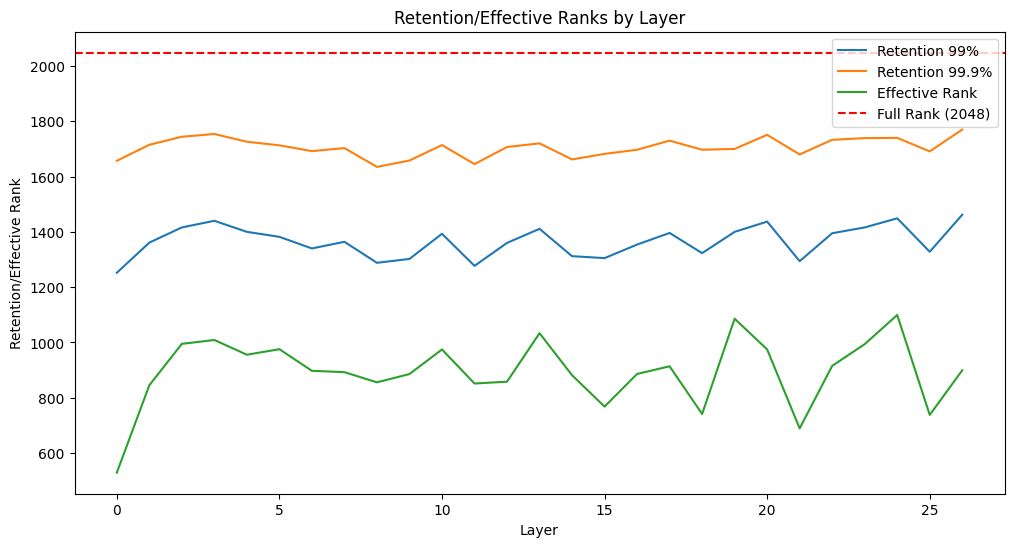

In [23]:
# Plot the  
ax = svd_layers_df_expanded.plot(x='layer', y=['r99', 'r99.9', 'entropy_based_effective_rank'], figsize=(12, 6))

# Add a custom horizontal line
_ = plt.axhline(y=WO[0].shape[0], color='red', linestyle='--', label='Threshold Line')

# Add titles, labels and legend
_ = plt.ylabel('Retention/Effective Rank')
_ = plt.xlabel('Layer')
_ = plt.title('Retention/Effective Ranks by Layer')
_ = ax.legend(['Retention 99%', 'Retention 99.9%', "Effective Rank", f"Full Rank ({WO[0].shape[0]})"])
plt.show()

## Calculate the average value across the different layers

In [24]:
# Calculate and print with 2-digit precision
print(f"Average Retention 99%: {svd_layers_df_expanded['r99'].mean():.2f}")
print(f"Average Retention 99.9%: {svd_layers_df_expanded['r99.9'].mean():.2f}")
print(f"Average Effective Rank (Entropy): {svd_layers_df_expanded['entropy_based_effective_rank'].mean():.2f}")

Average Retention 99%: 1365.07
Average Retention 99.9%: 1705.74
Average Effective Rank (Entropy): 894.14


## Conclusion
From this plot I can confirm that I believe the DeepSeek V2 Lite models output projection matrix $W_O$ is also moderately overparameterised with an effective rank of approx 900 on average, over 50% lower than the full rank. The fact that the effective rank is so far below even the 99% line suggests that many of the dimensions the model is using are highly correlated or redundant. However, compared to the other models, we can see that there is alot more variance in the effective and retention based rank curves. There is a possibility that this could be related to the MoE architecture. Since different layers activate different experts, the structural density of the weights fluctuates. Some layers are specialized and low-rank, while others are generalists that require a higher rank to process multifaceted information. To conclude it would appear that one could apply some form of compression to the output projection ideally retaining model performance while reducing its parameter count.